# W6: Random Forest Metrics + Lin Reg Metrics

## Importing Data and Libraries

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_curve, roc_auc_score
import numpy as np
import seaborn as sns

In [97]:
df=pd.read_csv("titanicdataset.csv", header=1)#the header is the first row of the dataset
df.rename(columns={df.columns[3]: 'name'}, inplace=True)# replacing the 4th column with name
df.head()

,sn,pclass,survived,name,gender,age,family,fare,embarked,date
0,1,3,0,Mr. Anthony,male,42,0.0,7.55,NaN,01-Jan-90
1,1,3,0,Mr. Anthony,male,42,0.0,7.55,NaN,01-Jan-90
2,2,3,0,Master. Eugene Joseph,male,?,2.0,20.25,S,02-Jan-90
3,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2.0,**,S,03-Jan-90
4,4,3,1,"Abbott, Mr. Rossmore Edward",female,35,2.0,20.25,S,04-Jan-90


In [101]:
wrong_gender_count=df[(df['name'].str.contains('Mr.', regex=False)) & (df['gender'] != 'male')]
print (wrong_gender_count)
df = df.drop(df[(df['name'].str.contains('Mr.', regex=False)) & (df['gender'] == 'female')].index)

   sn  pclass  survived                         name  gender  age  family  \
3   3       2         0  Abbott, Mr. Rossmore Edward     NaN  NaN     2.0   
4   4       3         1  Abbott, Mr. Rossmore Edward  female   35     2.0   

    fare embarked       date  
3     **        S  03-Jan-90  
4  20.25        S  04-Jan-90  


In [105]:
df.describe()

,sn,pclass,survived,family
count,1300.000000,1300.000000,1300.000000,1298.000000
mean,650.497692,2.289231,0.383846,0.889060
std,375.425971,0.838475,0.486508,1.588321
min,1.000000,1.000000,0.000000,0.000000
25%,325.750000,2.000000,0.000000,0.000000
50%,650.500000,3.000000,0.000000,0.000000
75%,975.250000,3.000000,1.000000,1.000000
max,1300.000000,3.000000,1.000000,10.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sn        1301 non-null   int64  
 1   pclass    1301 non-null   int64  
 2   survived  1301 non-null   int64  
 3   name      1301 non-null   object 
 4   gender    1300 non-null   object 
 5   age       1044 non-null   object 
 6   family    1299 non-null   float64
 7   fare      1299 non-null   object 
 8   embarked  1295 non-null   object 
 9   date      1301 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 101.8+ KB


## Cleaning the Data

In [102]:
clean_df=df.copy()
clean_df=clean_df.drop_duplicates()
clean_df=clean_df.replace({'?': np.nan, '**': np.nan})
clean_df['age']=pd.to_numeric(clean_df['age'])#changing age to integer
clean_df['fare']=pd.to_numeric(clean_df['fare'])#changing fare to integer
clean_df['age']=clean_df['age'].fillna(clean_df['age'].median())#filling age with median
clean_df['fare']=clean_df['fare'].fillna(clean_df['fare'].median())#filling empty fares with median
clean_df['family']=clean_df['family'].fillna(clean_df['family'].median())#filling empty family values with median
clean_df['gender']=clean_df['gender'].fillna('male')#filling NaNs with male
clean_df['gender']=clean_df['gender'].map({'male': 0, 'female': 1})

In [103]:
clean_df.head()

,sn,pclass,survived,name,gender,age,family,fare,embarked,date
0,1,3,0,Mr. Anthony,0,42.0,0.0,7.5500,NaN,01-Jan-90
2,2,3,0,Master. Eugene Joseph,0,28.0,2.0,20.2500,S,02-Jan-90
3,3,2,0,"Abbott, Mr. Rossmore Edward",0,28.0,2.0,14.4542,S,03-Jan-90
5,5,3,1,"Abelseth, Miss. Karen Marie",1,16.0,0.0,7.6500,S,05-Jan-90
6,6,3,1,"Abelseth, Mr. Olaus Jorgensen",0,25.0,0.0,7.6500,S,06-Jan-90


In [104]:
clean_df.describe()

,sn,pclass,survived,gender,age,family,fare
count,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000,1299.000000
mean,650.997691,2.288684,0.384142,0.357198,29.572687,0.888376,33.448402
std,375.137305,0.838566,0.486579,0.479358,12.889293,1.587901,51.902631
min,1.000000,1.000000,0.000000,0.000000,0.170000,0.000000,0.000000
25%,326.500000,2.000000,0.000000,0.000000,22.000000,0.000000,7.895800
50%,651.000000,3.000000,0.000000,0.000000,28.000000,0.000000,14.454200
75%,975.500000,3.000000,1.000000,1.000000,35.000000,1.000000,31.275000
max,1300.000000,3.000000,1.000000,1.000000,80.000000,10.000000,512.329200


In [106]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1299 entries, 0 to 1300
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sn        1299 non-null   int64  
 1   pclass    1299 non-null   int64  
 2   survived  1299 non-null   int64  
 3   name      1299 non-null   object 
 4   gender    1299 non-null   int64  
 5   age       1299 non-null   float64
 6   family    1299 non-null   float64
 7   fare      1299 non-null   float64
 8   embarked  1294 non-null   object 
 9   date      1299 non-null   object 
dtypes: float64(3), int64(4), object(3)
memory usage: 111.6+ KB


## Graphs

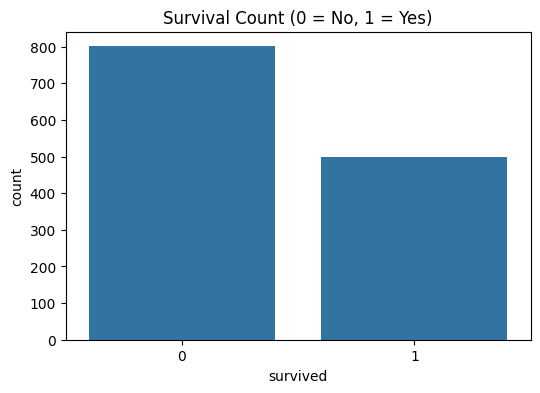

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(data=clean_df, x='survived')
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

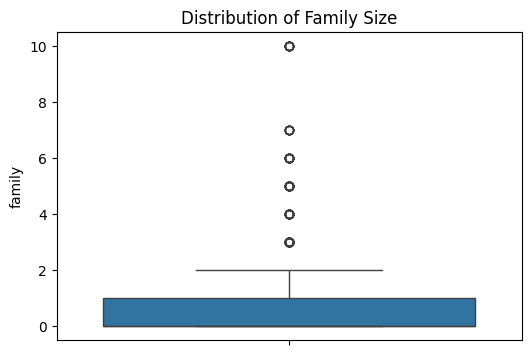

In [53]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=clean_df['family'])
plt.title('Distribution of Family Size')
plt.show()

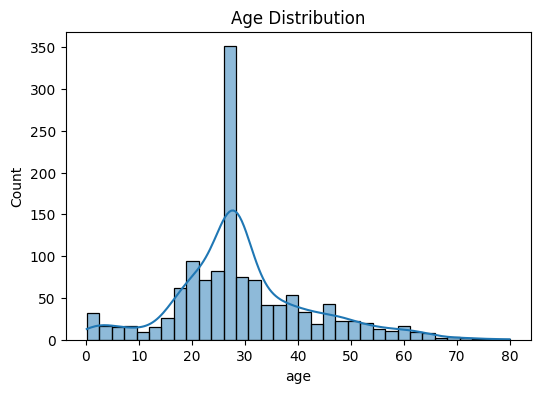

In [47]:
plt.figure(figsize=(6, 4))
sns.histplot(clean_df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

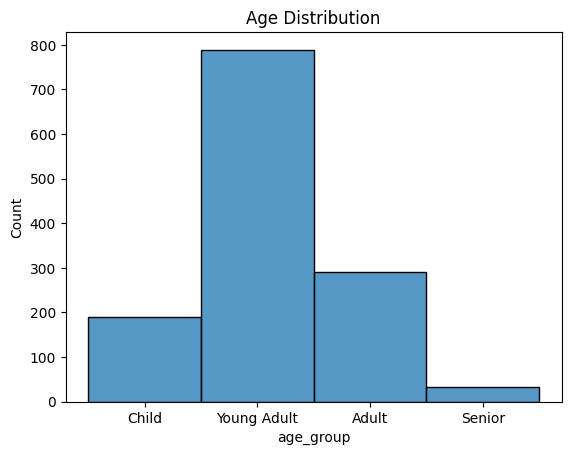

In [71]:
clean_df['age_group']=pd.cut(clean_df['age'], bins=[0, 18, 35, 60, 80], labels=["Child", "Young Adult", "Adult", "Senior"])
sns.histplot(clean_df['age_group'])
plt.title('Age Distribution')
plt.show()

## Initial Split

In [32]:
X=clean_df.drop(['sn','survived','name','date','embarked'], axis=1)
y=clean_df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

- a random state parameter acts as a seed for the random number generator. Setting it ensures that the data is shuffled and split the exact same way every time you run the code so you can refer to it later on.

## Training the Tree

In [33]:
deep_tree=DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)

train_acc=accuracy_score(y_train, deep_tree.predict(X_train))
test_acc=accuracy_score(y_test, deep_tree.predict(X_test))

print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy: {test_acc * 100:.2f}%")

Training Accuracy: 96.73%
Testing Accuracy: 73.18%


- The model has overfitted
- It grew so deep that it basically memorized the specifics of the training set rather than learning the general patterns of the dataset
- So it fails to generalize to the test data.

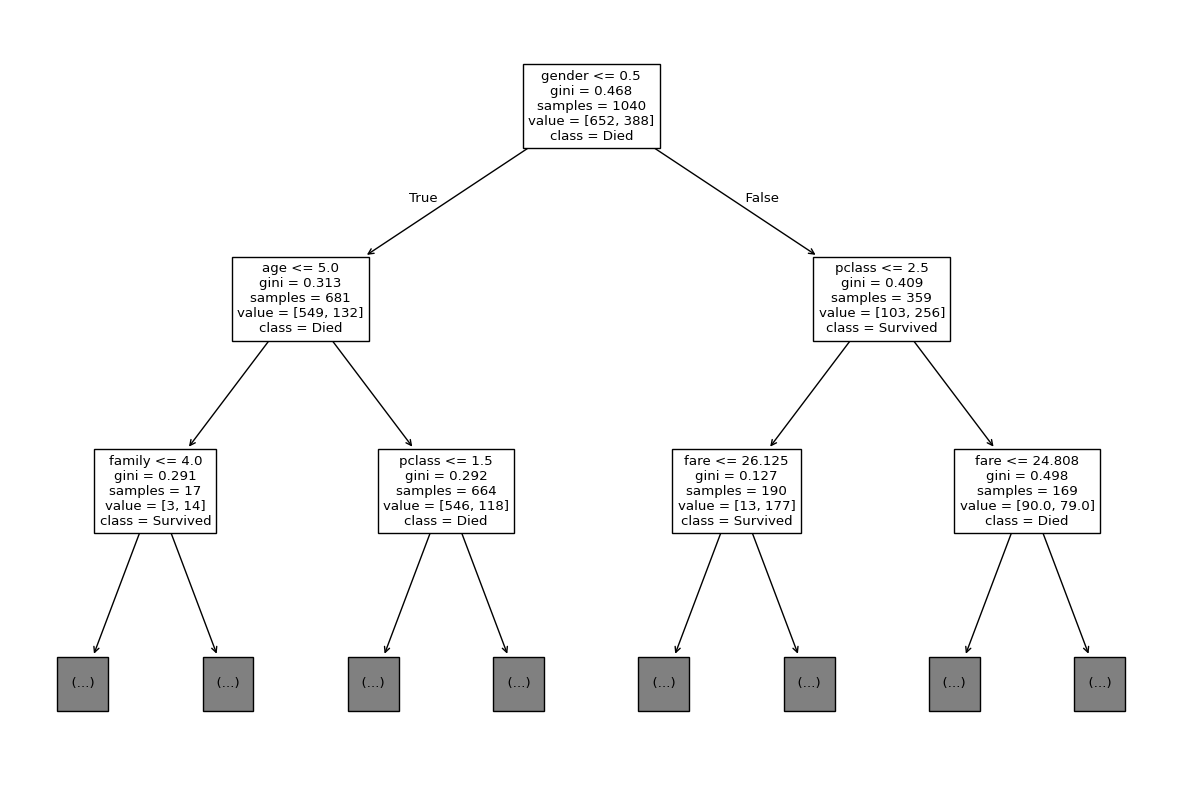

In [34]:
plt.figure(figsize=(15, 10))
plot_tree(deep_tree, max_depth=2, feature_names=X.columns, class_names=['Died', 'Survived'])
plt.show()

- The model chose gender as the very first split
- this makes sense based on the titanic history
- the historical protocol during the sinking was women and children first for the lifeboat

In [35]:
max_3_tree=DecisionTreeClassifier(random_state=1, max_depth=3)
max_3_tree.fit(X_train, y_train)

train_3=accuracy_score(y_train, max_3_tree.predict(X_train))
test_3=accuracy_score(y_test, max_3_tree.predict(X_test))

print(f"Training Accuracy: {train_3 * 100:.2f}%")
print(f"Testing Accuracy: {test_3 * 100:.2f}%")

Training Accuracy: 80.58%
Testing Accuracy: 81.61%


- the max depth helps the model because it reduces overfitting

## Using Random Forest Classifier

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf=RandomForestClassifier(n_estimators=100, max_depth=None, random_state=2)
clf.fit(X_train, y_train)
y_pred=clf.predict(X_test)
accuracy=accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 80.46%


- Because you are combining the predictions from many decision trees, it reduces the risk of overfitting compared to a single decision tree.

## Confusion Matrix

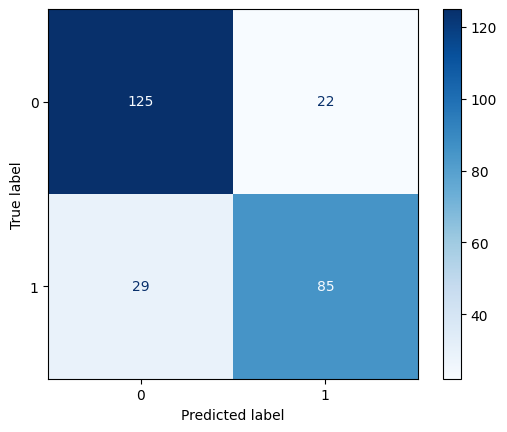

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=True, cmap='Blues')
plt.show()

- The model predicted 22 passengers would survive who actually died
- It also predicted 29 passengers would die who actually survived

## Precision and Recall

In [46]:
print(f'Precision score: {precision_score(y_test, y_pred) *100:.2f}%')
print(f'Recall score: {recall_score(y_test, y_pred) *100:.2f}%')

Precision score: 79.44%
Recall score: 74.56%


- If you were a rescue coordinator whose goal was to "leave no one behind," you would be more concerned with maximizing Recall
- Recall measures tbe proportion of actual surviors that were correctly identified by the model

## ROC AUC

ROC AUC Score: 0.86


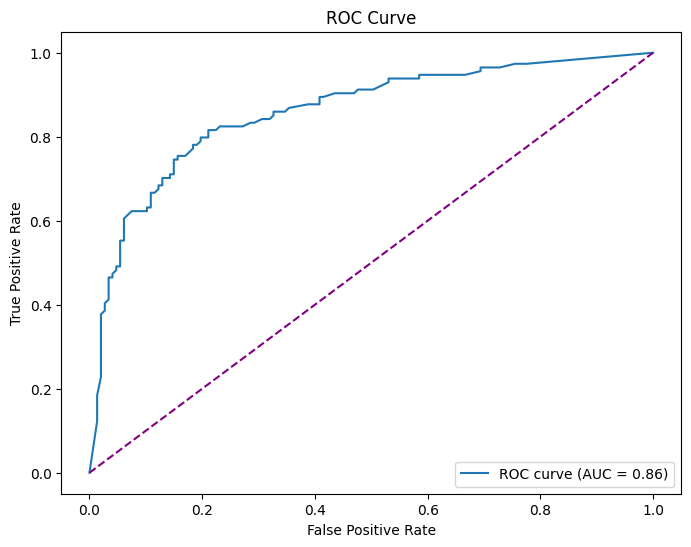

In [39]:
rf_probs=clf.predict_proba(X_test)[:, 1] 
auc_score=roc_auc_score(y_test, rf_probs)

print(f"ROC AUC Score: {auc_score:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='purple', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

- An AUC score of 0.85 is quite strong
- The ROC hugs the left corner which is also good
- An AUC of 0.85 says that if you randomly select one actual survivor and one actual victim from your dataset, there is an 85% chance that the model will assign a higher probability of survival to the survivor than to the victim.

## Feature Importance

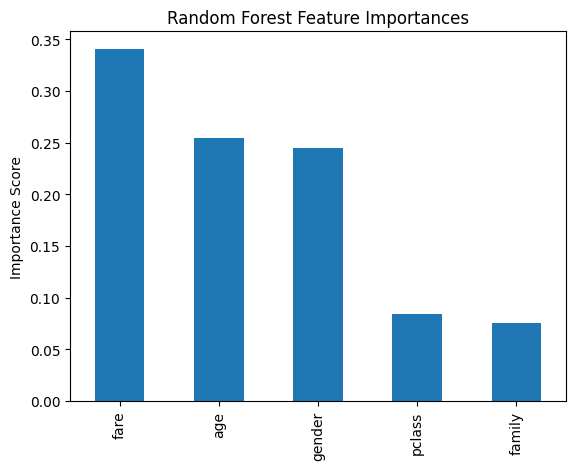

In [67]:
features = ['pclass', 'gender', 'age', 'family', 'fare']
importances=clf.feature_importances_
feature_imp_series=pd.Series(importances, index=features).sort_values(ascending=False)

feature_imp_series.plot(kind='bar')
plt.title('Random Forest Feature Importances')
plt.ylabel('Importance Score')
plt.show()

- The top three features were fare, gender and age
- There were no features that were completely useless, but family and passenger class did not contribute much to the model